# Privacy and Governance Analysis
## Analysis Overview

This notebook analyzes potential privacy and fairness issues in a loan approval system.

The analysis focuses on:

- identifying sensitive attributes and personally identifiable information (PII)
- evaluating whether approval decisions differ across gender groups
- computing the Disparate Impact Ratio (DIR) to assess potential bias
- examining variables such as income or ZIP code that may act as proxy indicators

The objective is to evaluate potential risks related to bias, discrimination, and privacy from a data governance perspective.


## Step 1 — Import libraries

We import the standard libraries for data processing and visualization.

These tools enable dataset inspection, fairness metric computation, and governance reporting through plots and tables.

In [519]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2 — Load and normalize the dataset

The dataset is provided as a **nested JSON**.
We load the file and use `pd.json_normalize()` to create a tabular structure suitable for analysis.

This is a key governance step because governance controls (privacy/fairness checks) require clear visibility of all fields.

In [520]:
with open("../data/raw_credit_applications.json") as f:
    data = json.load(f)

df = pd.json_normalize(data)
df.columns
df.head()

,_id,spending_behavior,processing_timestamp,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,...,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.loan_approved,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount,financials.annual_salary,notes
0,app_200,"[{'category': 'Shopping', 'amount': 480}, {'ca...",2024-01-15T00:00:00Z,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,Male,2001-03-09,10036,...,23,0.20,31212,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
1,app_037,"[{'category': 'Rent', 'amount': 608}, {'catego...",NaN,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,M,1992-03-31,10032,...,51,0.18,17915,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
2,app_215,"[{'category': 'Rent', 'amount': 109}]",NaN,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,Male,1989-10-24,10075,...,41,0.21,37909,True,NaN,vacation,3.7,59000.0,NaN,NaN
3,app_024,"[{'category': 'Fitness', 'amount': 575}]",NaN,Thomas Lee,thomas.lee6@protonmail.com,194-35-1833,192.168.175.67,Male,1983-04-25,10077,...,70,0.35,0,True,NaN,NaN,4.3,34000.0,NaN,NaN
4,app_184,"[{'category': 'Entertainment', 'amount': 463}]",2024-01-15T00:00:00Z,Brian Rodriguez,brian.rodriguez86@aol.com,480-41-2475,172.29.125.105,M,1999-05-21,10080,...,14,0.23,31763,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN


## Step 3 — Inspect dataset structure

We inspect the dataset structure using `df.info()` to review data types, missing values, and the overall schema.

This step replicates a basic inspection that was already performed during the **data preparation phase by the data scientist and data engineering team**.
However, from a **governance perspective**, it is useful to briefly verify the structure of the dataset to ensure transparency and confirm that the data used for the fairness analysis is consistent and correctly formatted.

Performing this check helps support **data quality validation** and ensures that subsequent governance analyses are based on a reliable dataset.

In [521]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 21 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   _id                               502 non-null    object 
 1   spending_behavior                 502 non-null    object 
 2   processing_timestamp              62 non-null     object 
 3   applicant_info.full_name          502 non-null    object 
 4   applicant_info.email              502 non-null    object 
 5   applicant_info.ssn                497 non-null    object 
 6   applicant_info.ip_address         497 non-null    object 
 7   applicant_info.gender             501 non-null    object 
 8   applicant_info.date_of_birth      501 non-null    object 
 9   applicant_info.zip_code           501 non-null    object 
 10  financials.annual_income          497 non-null    object 
 11  financials.credit_history_months  502 non-null    int64  
 12  financia

## Step 4 — Identify sensitive attributes and PII

From a governance perspective, we classify attributes into:

- **Sensitive attributes** (e.g., gender, age derived from date_of_birth) → fairness risks
- **Proxy variables** (e.g., ZIP code) → potential indirect discrimination
- **PII** (e.g., SSN, email, IP address) → privacy and re-identification risks

This classification supports privacy governance practices such as data minimization, access control, and risk documentation.

In [522]:
sensitive_data = {
    "Attribute": [
        "applicant_info.gender",
        "applicant_info.date_of_birth",
        "applicant_info.zip_code",
        "applicant_info.ssn",
        "applicant_info.email",
        "applicant_info.ip_address"
    ],
    "Category": [
        "Sensitive attribute",
        "Sensitive attribute",
        "Sensitive attribute (proxy)",
        "Personally Identifiable Information (PII)",
        "Personally Identifiable Information (PII)",
        "Personally Identifiable Information (PII)"
    ],
    "Risk Type": [
        "Gender discrimination",
        "Age discrimination",
        "Proxy discrimination",
        "Identity exposure",
        "Personal identification",
        "User tracking"
    ]
}

sensitive_table = pd.DataFrame(sensitive_data)

sensitive_table

,Attribute,Category,Risk Type
0,applicant_info.gender,Sensitive attribute,Gender discrimination
1,applicant_info.date_of_birth,Sensitive attribute,Age discrimination
2,applicant_info.zip_code,Sensitive attribute (proxy),Proxy discrimination
3,applicant_info.ssn,Personally Identifiable Information (PII),Identity exposure
4,applicant_info.email,Personally Identifiable Information (PII),Personal identification
5,applicant_info.ip_address,Personally Identifiable Information (PII),User tracking


## Step 5 — Privacy control: Pseudonymization of PII

After identifying PII fields (e.g., full name, email, SSN, and IP address), we apply pseudonymization by replacing the original values with salted SHA-256 hashes.

This creates columns such as:

- `applicant_info.full_name_hash`
- `applicant_info.email_hash`
- `applicant_info.ssn_hash`
- `applicant_info.ip_address_hash`

The method used is hash-based pseudonymization, where a one-way cryptographic function (SHA-256) converts the original value into a fixed-length hash. A salt is added before hashing to reduce the risk of brute-force or dictionary attacks.

This approach differs from other techniques:
- Tokenization requires a lookup table linking tokens to original values.
- Encryption is reversible using a secret key.

In contrast, hashing is one-way and does not require a mapping table, which is consistent with the pseudonymization method used here.

From a governance perspective, this reduces exposure of direct identifiers and supports data minimization, while still allowing analysis on a dataset (`df_privacy`) where raw PII has been removed.

Importantly, quasi-identifiers (e.g., gender, ZIP code) are intentionally retained in the dataset because they are necessary for fairness analysis and proxy discrimination detection. Techniques such as k-anonymity could reduce re-identification risk by generalizing these variables, but they were not applied here because attributes like gender and ZIP code are required for bias detection and fairness evaluation.

Note that pseudonymization is not anonymization: under GDPR, pseudonymized data is still considered personal data.

In [523]:

import os
import hashlib

PII_COLS = [
    "applicant_info.full_name",   # if present in dataset
    "applicant_info.email",
    "applicant_info.ssn",
    "applicant_info.ip_address"
]

PII_COLS = [c for c in PII_COLS if c in df.columns]


SALT = os.getenv("PSEUDO_SALT")


if not SALT:
    SALT = "DEMO_ONLY_CHANGE_ME_AND_STORE_SECURELY"


def salted_sha256(value, salt):
    """
    Stable pseudonymization using salted SHA-256.
    Returns NA if value is missing.
    """
    if pd.isna(value):
        return pd.NA

    value = str(value).strip()

    if value == "":
        return pd.NA

    return hashlib.sha256((salt + value).encode("utf-8")).hexdigest()


for col in PII_COLS:
    df[col + "_hash"] = df[col].apply(lambda x: salted_sha256(x, SALT))



df_privacy = df.copy()
df_privacy = df_privacy.drop(columns=PII_COLS, errors="ignore")

print("=== Pseudonymization completed ===")
print("Columns hashed:", [c + "_hash" for c in PII_COLS])
print("Raw PII removed from df_privacy:", PII_COLS)


if PII_COLS:
    display(df_privacy[[c + "_hash" for c in PII_COLS]].head())
else:
    print("No PII columns found in dataset.")

=== Pseudonymization completed ===
Columns hashed: ['applicant_info.full_name_hash', 'applicant_info.email_hash', 'applicant_info.ssn_hash', 'applicant_info.ip_address_hash']
Raw PII removed from df_privacy: ['applicant_info.full_name', 'applicant_info.email', 'applicant_info.ssn', 'applicant_info.ip_address']


,applicant_info.full_name_hash,applicant_info.email_hash,applicant_info.ssn_hash,applicant_info.ip_address_hash
0,ba096c86c1cfc125bcfad3f50803ac275c9bf7887b7171...,36cbac2c92613dcc1347b07435fad13f98f5532e42f0e5...,ddb61615f4cae0cde238021b12800ae40cad93d121884d...,bc05ce55e86f0abe9fc721a7eda3bd65b2a33d944d74bd...
1,b8338fc3222a6697c64dc3b83f9992674b7091cbab264b...,1688be51d7445df37715215c7e8dc85752992b95de8658...,a1db7207c57f46a5502e8b2e755f759bc12a94c1cf44ec...,10feb108356840f2feec1816ef8b453821d300a21e8d48...
2,b4cd70fd0380b676fddf9f0e3a4a505ac7f551a3cd0bdd...,529b0c5c5be077653e1535482304aead1153768b42787b...,7c7faed93e3268b1cb11feb41d2473642358877b7a7732...,a868237a38ddb9192185a811caff3d2b88e4632415ced0...
3,e9e031b167e684179e116dd9e7c4676c0b4a042d69b92f...,8712260069d9d386f37f649ffec45f33ecb97fd9bc1e93...,a19a4afe67f8872cf9d02a46860f89fb0fb21a11cf7378...,897b66c648382fce39c3f965be02aa8cbd827d1b33c782...
4,37da1ce2343a5d8267b1442fd83f3cf788ad3f445dad98...,f5f2357689208cca22e21323a224fd4293d570187d43ff...,77695ac7b0247e1b31cd5d7776a0d1521c6cef04c92a42...,8ecd1fd8dfd4d155a8c47bfb477a775aa80f6a2bbb713b...


In [524]:
df_privacy

,_id,spending_behavior,processing_timestamp,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,financials.annual_income,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,...,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount,financials.annual_salary,notes,applicant_info.full_name_hash,applicant_info.email_hash,applicant_info.ssn_hash,applicant_info.ip_address_hash
0,app_200,"[{'category': 'Shopping', 'amount': 480}, {'ca...",2024-01-15T00:00:00Z,Male,2001-03-09,10036,73000,23,0.20,31212,...,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN,ba096c86c1cfc125bcfad3f50803ac275c9bf7887b7171...,36cbac2c92613dcc1347b07435fad13f98f5532e42f0e5...,ddb61615f4cae0cde238021b12800ae40cad93d121884d...,bc05ce55e86f0abe9fc721a7eda3bd65b2a33d944d74bd...
1,app_037,"[{'category': 'Rent', 'amount': 608}, {'catego...",NaN,M,1992-03-31,10032,78000,51,0.18,17915,...,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN,b8338fc3222a6697c64dc3b83f9992674b7091cbab264b...,1688be51d7445df37715215c7e8dc85752992b95de8658...,a1db7207c57f46a5502e8b2e755f759bc12a94c1cf44ec...,10feb108356840f2feec1816ef8b453821d300a21e8d48...
2,app_215,"[{'category': 'Rent', 'amount': 109}]",NaN,Male,1989-10-24,10075,61000,41,0.21,37909,...,NaN,vacation,3.7,59000.0,NaN,NaN,b4cd70fd0380b676fddf9f0e3a4a505ac7f551a3cd0bdd...,529b0c5c5be077653e1535482304aead1153768b42787b...,7c7faed93e3268b1cb11feb41d2473642358877b7a7732...,a868237a38ddb9192185a811caff3d2b88e4632415ced0...
3,app_024,"[{'category': 'Fitness', 'amount': 575}]",NaN,Male,1983-04-25,10077,103000,70,0.35,0,...,NaN,NaN,4.3,34000.0,NaN,NaN,e9e031b167e684179e116dd9e7c4676c0b4a042d69b92f...,8712260069d9d386f37f649ffec45f33ecb97fd9bc1e93...,a19a4afe67f8872cf9d02a46860f89fb0fb21a11cf7378...,897b66c648382fce39c3f965be02aa8cbd827d1b33c782...
4,app_184,"[{'category': 'Entertainment', 'amount': 463}]",2024-01-15T00:00:00Z,M,1999-05-21,10080,57000,14,0.23,31763,...,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN,37da1ce2343a5d8267b1442fd83f3cf788ad3f445dad98...,f5f2357689208cca22e21323a224fd4293d570187d43ff...,77695ac7b0247e1b31cd5d7776a0d1521c6cef04c92a42...,8ecd1fd8dfd4d155a8c47bfb477a775aa80f6a2bbb713b...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
497,app_468,"[{'category': 'Transportation', 'amount': 701}]",NaN,Male,1999-05-23,10046,22000,35,0.35,8982,...,insufficient_credit_history,NaN,NaN,NaN,NaN,NaN,bdbf5371d6c7c03de678ea4552a9062ab4a6ff5e55b08a...,7e0a7d56ba08654e4ad52a9dec5239196cbd92701c4400...,6bc8977db4671870f2612bde8011e9c0f31f3e11ccc270...,5a9be6a8dc628ca4a4693540f1ddf179227315dd3c206c...
498,app_192,"[{'category': 'Healthcare', 'amount': 650}]",2024-01-15T00:00:00Z,Male,11/15/1985,10088,78000,40,0.22,34292,...,NaN,NaN,6.0,18000.0,NaN,NaN,f5004447abbeee87d7e9a101c659f3b8358c51af79249d...,aaf242ca806b0ed8e35af9a4c1e89bad87780adbf5ecd1...,7b36636682b09d26d027f05d309e6b990b76cacf437494...,caa644be4be11da102a8c474e877fdbcdf26a49241f797...
499,app_234,"[{'category': 'Insurance', 'amount': 526}]",NaN,Male,1976/01/29,10090,96000,60,0.30,38703,...,algorithm_risk_score,education,NaN,NaN,NaN,NaN,9b2cb7ac48b74fc7b8aa49bc8e9809b49f4b6439d6a3a0...,e85c9f93191e73bad1a68effcdf4c94f9e19d952362439...,719ed54942cf82cc8d2dda512877a6f6ed6298391fb107...,fa204341e34ac11f49ed7391d219452d574c92a3a01189...
500,app_306,"[{'category': 'Insurance', 'amount': 490}]",NaN,Female,1978-07-26,90227,106000,80,0.29,63560,...,NaN,NaN,3.1,57000.0,NaN,NaN,1aef84c80ff19756bd9bf04bb48edc96b017772182bdbb...,cb29e0d6ef068443e14c70e3cde42add5d86410e85b9d7...,5cf12d2c113c55ad50522d03c56bf1341d189b21f45e1e...,f445fe0cb5441d94e327da31639240a9d0074c01ae227d...


## Fairness Metrics — Scope and Limitations

The fairness evaluation focuses on outcome-based metrics such as Demographic Parity and the Disparate Impact Ratio (DIR).

Metrics such as Equalized Odds and Predictive Parity cannot be computed in this analysis because the dataset does not include ground-truth outcomes (e.g., whether loans were actually repaid or defaulted).

## Step 6— Outcome disparity and fairness metric (DIR)

We compute the **approval rate** by gender to detect disparities in outcomes.

Then we compute the **Disparate Impact Ratio (DIR)**:

DIR = Approval Rate (Female) / Approval Rate (Male)

A commonly used guideline is the **80% rule**: if DIR < 0.8, outcomes may indicate potential **disparate impact**.
This is a standard step in fairness audits and Responsible AI governance.

In [533]:
import json
import pandas as pd
import numpy as np

# -----------------------------
# Load original raw dataset (JSON -> tabular)
# -----------------------------
with open("../data/raw_credit_applications.json") as f:
    data = json.load(f)

df = pd.json_normalize(data)

# -----------------------------
# Minimal normalization needed to compute fairness metrics reliably
# (does NOT remove rows except invalid gender/decision)
# -----------------------------

# 1) Clean/standardize gender into a derived column (keeps original intact)
g = (
    df["applicant_info.gender"]
    .astype(str)
    .str.strip()
    .str.lower()
)

df["gender_clean"] = g.map({
    "m": "Male",
    "male": "Male",
    "1": "Male",
    "f": "Female",
    "female": "Female",
    "2": "Female",
})

# 2) Ensure decision is clean numeric/bool-like (0/1)
#    (handles True/False, 0/1, "true"/"false", etc.)
decision_raw = df["decision.loan_approved"]

if decision_raw.dtype == bool:
    df["loan_approved_clean"] = decision_raw.astype(int)
else:
    df["loan_approved_clean"] = (
        decision_raw.astype(str).str.strip().str.lower()
        .replace({"true": 1, "false": 0, "yes": 1, "no": 0})
    )
    df["loan_approved_clean"] = pd.to_numeric(df["loan_approved_clean"], errors="coerce")

# 3) Keep only records usable for the metric
df_fair = df[df["gender_clean"].isin(["Male", "Female"])].copy()
df_fair = df_fair.dropna(subset=["loan_approved_clean"])

# -----------------------------
# Approval rate + gap + Disparate Impact Ratio (DIR)
# -----------------------------
approval_by_gender = df_fair.groupby("gender_clean")["loan_approved_clean"].mean()

female_rate = approval_by_gender.get("Female", np.nan)
male_rate = approval_by_gender.get("Male", np.nan)

print("=== Approval Rate by Gender (cleaned for metric) ===")
print(approval_by_gender)

print("\n=== Approval Rate (percent) ===")
print(f"Female approval rate: {female_rate:.4f} ({female_rate * 100:.2f}%)")
print(f"Male approval rate:   {male_rate:.4f} ({male_rate * 100:.2f}%)")

diff_pp = (male_rate - female_rate) * 100
print("\n=== Approval Gap ===")
print(f"Difference (Male - Female): {diff_pp:.2f} percentage points")

DIR = female_rate / male_rate
print("\n=== Disparate Impact Ratio (DIR) ===")
print(f"DIR = {DIR:.3f}")

print("\n=== Fairness Interpretation ===")
if np.isfinite(DIR) and DIR < 0.8:
    print("The DIR is below the 0.8 fairness threshold (80% rule).")
    print("This may indicate potential disparate impact / gender bias risk.")
else:
    print("DIR is at/above 0.8 or not computable with current data.")
    print("No disparate impact flagged by this metric alone.")

# Optional: show how many records were used
print("\n=== Sample sizes used ===")
print(df_fair["gender_clean"].value_counts())

=== Approval Rate by Gender (cleaned for metric) ===
gender_clean
Female    0.505976
Male      0.657258
Name: loan_approved_clean, dtype: float64

=== Approval Rate (percent) ===
Female approval rate: 0.5060 (50.60%)
Male approval rate:   0.6573 (65.73%)

=== Approval Gap ===
Difference (Male - Female): 15.13 percentage points

=== Disparate Impact Ratio (DIR) ===
DIR = 0.770

=== Fairness Interpretation ===
The DIR is below the 0.8 fairness threshold (80% rule).
This may indicate potential disparate impact / gender bias risk.

=== Sample sizes used ===
gender_clean
Female    251
Male      248
Name: count, dtype: int64


## Step 7 — Visualize Disparate Impact Ratio

We visualize the DIR and the fairness threshold (0.8) to make the governance conclusion more interpretable.

Visual thresholds improve communication of fairness risks to non-technical stakeholders (a key governance requirement).


=== Disparate Impact Ratio (DIR) ===
DIR (Female/Male) = 0.770
 DIR < 0.8 (80% rule) → potential adverse impact / disparate impact risk.


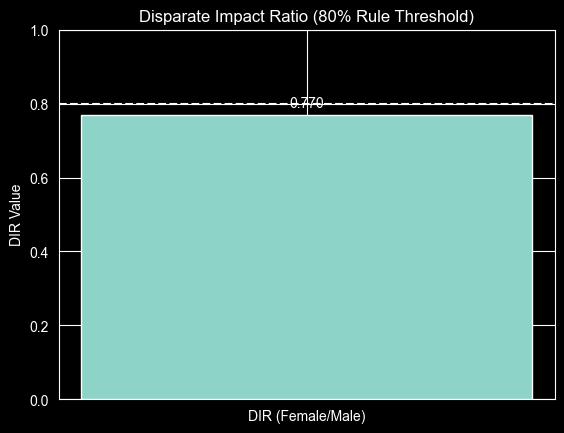

In [534]:
print("\n=== Disparate Impact Ratio (DIR) ===")
print(f"DIR (Female/Male) = {DIR:.3f}")

threshold = 0.8
if DIR < threshold:
    print(" DIR < 0.8 (80% rule) → potential adverse impact / disparate impact risk.")
else:
    print("DIR ≥ 0.8 → no adverse impact detected by this metric.")

plt.figure()
plt.bar(["DIR (Female/Male)"], [DIR])
plt.axhline(threshold, linestyle="--")
plt.title("Disparate Impact Ratio (80% Rule Threshold)")
plt.ylabel("DIR Value")
plt.ylim(0, 1)


plt.text(0, DIR + 0.02, f"{DIR:.3f}", ha="center")

plt.show()

## Step 8 — Income distribution by gender

We examine the distribution of annual income across gender groups using a boxplot.

Income may act as a **proxy variable**, meaning that differences in income distribution could indirectly influence model outcomes and contribute to **proxy discrimination**.

Note: A small number of records contain missing values for annual income.
These records are automatically excluded from this analysis, resulting in a slightly smaller sample size compared to previous steps.

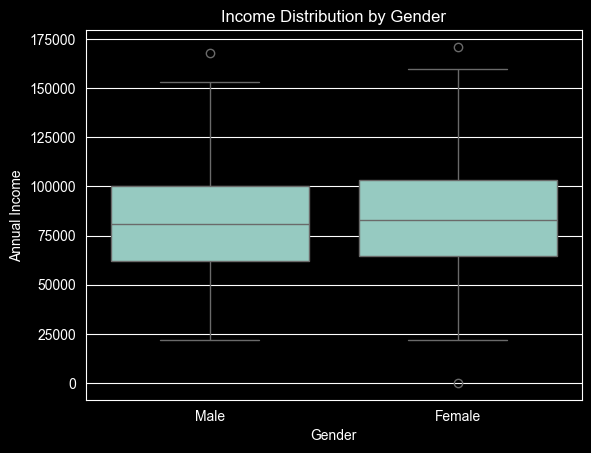


Income statistics by gender:
              count          mean           std      min      25%      50%  \
gender_clean                                                                 
Female        247.0  83912.683357  28751.470073      0.0  64500.0  83000.0   
Male          247.0  81388.663968  27486.632986  22000.0  62000.0  81000.0   

                   75%       max  
gender_clean                      
Female        103500.0  171000.0  
Male          100000.0  168000.0  


In [536]:
df_plot = df.copy()

df_plot["financials.annual_income"] = pd.to_numeric(
    df_plot["financials.annual_income"], errors="coerce"
)


if "gender_clean" not in df_plot.columns:
    g = df_plot["applicant_info.gender"].astype(str).str.strip().str.lower()
    df_plot["gender_clean"] = g.map({
        "m": "Male", "male": "Male", "1": "Male",
        "f": "Female", "female": "Female", "2": "Female"
    })

df_plot = df_plot.dropna(subset=["gender_clean", "financials.annual_income"])
df_plot = df_plot[df_plot["gender_clean"].isin(["Male", "Female"])]

sns.boxplot(
    x="gender_clean",
    y="financials.annual_income",
    data=df_plot
)

plt.title("Income Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Annual Income")
plt.show()

print("\nIncome statistics by gender:")
print(df_plot.groupby("gender_clean")["financials.annual_income"].describe())

## Step 9 — Demographic Parity / Outcome Disparity

In this step we evaluate **demographic parity**, a commonly used fairness metric that compares outcomes across demographic groups.

Specifically, we compute the "loan approval rate by gender" and measure the "approval gap" between male and female applicants.

This metric highlights "outcome disparity", meaning whether different groups receive systematically different decision outcomes.

From a governance perspective, this analysis helps identify potential group-level disparities in automated decision systems and complements the previously computed Disparate Impact Ratio (DIR).

The results are visualized using a bar chart to make the disparity easier to interpret and communicate to stakeholders involved in Responsible AI oversight.

=== Outcome disparity (Approval rate by gender) ===
gender_clean
Female    0.505976
Male      0.657258
Name: decision.loan_approved, dtype: float64

Female approval rate: 50.60%
Male approval rate:   65.73%
Approval gap (Male - Female): 15.13 percentage points


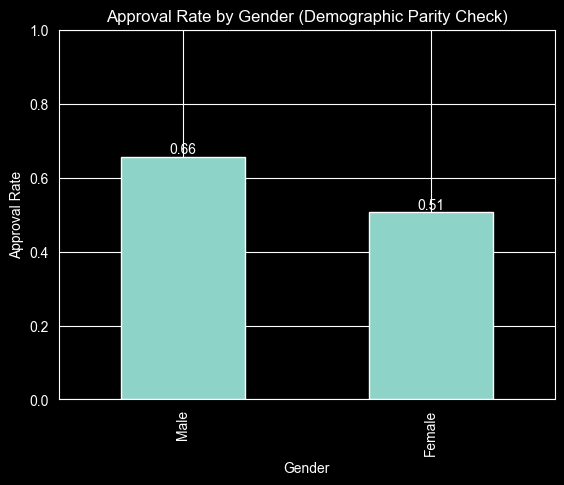

In [537]:
approval_rates = df.groupby("gender_clean")["decision.loan_approved"].mean()

female_rate = approval_rates.loc["Female"]
male_rate   = approval_rates.loc["Male"]

gap_pp = (male_rate - female_rate) * 100

print("=== Outcome disparity (Approval rate by gender) ===")
print(approval_rates)

print("\nFemale approval rate: {:.2f}%".format(female_rate * 100))
print("Male approval rate:   {:.2f}%".format(male_rate * 100))
print("Approval gap (Male - Female): {:.2f} percentage points".format(gap_pp))

# Plot
ax = approval_rates.reindex(["Male", "Female"]).plot(kind="bar")

plt.title("Approval Rate by Gender (Demographic Parity Check)")
plt.xlabel("Gender")
plt.ylabel("Approval Rate")
plt.ylim(0,1)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center",
                va="bottom")

plt.show()

## Step 10 — Proxy discrimination check (ZIP code)

In this step we examine whether **ZIP code** may act as a **proxy variable** that could indirectly influence model outcomes.

Proxy discrimination occurs when a variable that is not itself protected (such as ZIP code) is **strongly correlated with protected attributes** like race, income level, or socioeconomic status. Even if protected attributes are not explicitly used by the model, these proxy variables may still lead to **indirect discrimination**.

To investigate this risk, we compute the **loan approval rate for each ZIP code** and also examine the **number of applications per ZIP**. Considering the sample size is important, since very small groups can produce unstable approval rates.

By identifying ZIP codes with unusually **high or low approval rates**, we can detect potential geographic disparities that may signal **proxy bias** in the decision process.

In [538]:
if "df_g" not in globals():
    df_g = df[df["gender_clean"].isin(["Male", "Female"])].copy()
    df_g["financials.annual_income"] = pd.to_numeric(df_g["financials.annual_income"], errors="coerce")
    df_g["decision.loan_approved"] = pd.to_numeric(df_g["decision.loan_approved"], errors="coerce")
    df_g = df_g.dropna(subset=["decision.loan_approved", "gender_clean"])


df_g["zip_clean"] = df_g["applicant_info.zip_code"].astype(str).str.strip()


zip_stats = (
    df_g.groupby("zip_clean")["decision.loan_approved"]
    .agg(n="count", approval_rate="mean")
    .sort_values("n", ascending=False)
)

print("=== ZIP summary (top 10 by volume) ===")
display(zip_stats.head(10))

# Choose an appropriate minimum sample size automatically
max_n = int(zip_stats["n"].max()) if len(zip_stats) > 0 else 0
if max_n >= 10:
    min_n = 10
elif max_n >= 5:
    min_n = 5
elif max_n >= 3:
    min_n = 3
else:
    min_n = 1

zip_stats_filtered = zip_stats[zip_stats["n"] >= min_n].copy()

print(f"\nUsing min_n = {min_n} (max ZIP count in dataset = {max_n})")
print(f"ZIP codes kept for comparison: {zip_stats_filtered.shape[0]}")

print("\n=== ZIP codes with lowest approval rate (filtered) ===")
display(zip_stats_filtered.sort_values("approval_rate").head(10))

print("\n=== ZIP codes with highest approval rate (filtered) ===")
display(zip_stats_filtered.sort_values("approval_rate", ascending=False).head(10))

=== ZIP summary (top 10 by volume) ===


,n,approval_rate
zip_clean,,
10048,8,0.750000
90284,7,0.428571
10096,7,0.285714
10020,6,0.666667
10057,6,0.500000
10019,6,0.333333
10004,6,1.000000
10070,5,0.800000
10044,5,0.400000



Using min_n = 5 (max ZIP count in dataset = 8)
ZIP codes kept for comparison: 19

=== ZIP codes with lowest approval rate (filtered) ===


,n,approval_rate
zip_clean,,
10096,7,0.285714
10019,6,0.333333
10003,5,0.400000
10044,5,0.400000
90284,7,0.428571
10057,6,0.500000
10041,5,0.600000
10002,5,0.600000
90237,5,0.600000



=== ZIP codes with highest approval rate (filtered) ===


,n,approval_rate
zip_clean,,
10092,5,1.000000
10012,5,1.000000
10004,6,1.000000
90261,5,0.800000
10070,5,0.800000
90252,5,0.800000
90218,5,0.800000
10048,8,0.750000
10020,6,0.666667


## Step 11 — Confounding check: income brackets

In this step we investigate whether income may act as a "confounding variable" in the fairness analysis.

Income can be correlated both with gender and with the probability of loan approval. If this factor is not considered, observed disparities between groups might appear to be caused solely by gender, while they could partly reflect differences in income distribution.

To explore this, we divide applicants into income brackets (quartiles) and compute the loan approval rate by gender within each income group.

We then calculate the Disparate Impact Ratio (DIR)for each bracket by comparing the female approval rate to the male approval rate. This allows us to assess whether the disparity between genders persists even within similar income levels, or whether part of the observed gap can be explained by income differences.

This analysis helps distinguish between direct discrimination and the effects of correlated variables, supporting a more robust fairness evaluation of the automated decision system.

In [541]:

df_g["income_bracket"] = pd.qcut(
    df_g["financials.annual_income"],
    q=4,
    labels=["Q1_low", "Q2_midlow", "Q3_midhigh", "Q4_high"]
)

approval_income_gender = (
    df_g.groupby(["income_bracket", "gender_clean"])["decision.loan_approved"]
    .mean()
    .reset_index()
)

print("Approval rate by income bracket and gender:")
print(approval_income_gender)

pivot_inc = approval_income_gender.pivot(
    index="income_bracket",
    columns="gender_clean",
    values="decision.loan_approved"
)
pivot_inc["DIR_Female_over_Male"] = pivot_inc["Female"] / pivot_inc["Male"]

print("\nDisparate Impact Ratio within each income bracket:")
print(pivot_inc)

Approval rate by income bracket and gender:
  income_bracket gender_clean  decision.loan_approved
0         Q1_low       Female                0.322034
1         Q1_low         Male                0.523077
2      Q2_midlow       Female                0.426230
3      Q2_midlow         Male                0.682540
4     Q3_midhigh       Female                0.644068
5     Q3_midhigh         Male                0.738462
6        Q4_high       Female                0.617647
7        Q4_high         Male                0.685185

Disparate Impact Ratio within each income bracket:
gender_clean      Female      Male  DIR_Female_over_Male
income_bracket                                          
Q1_low          0.322034  0.523077              0.615653
Q2_midlow       0.426230  0.682540              0.624476
Q3_midhigh      0.644068  0.738462              0.872175
Q4_high         0.617647  0.685185              0.901431


/var/folders/x4/4xld017d1gx2ft5js9kc1s5m0000gn/T/ipykernel_38104/3579764658.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_g.groupby(["income_bracket", "gender_clean"])["decision.loan_approved"]
